<a href="https://colab.research.google.com/github/azl35/Hong-Kong-EV-adoption/blob/main/HK_EV_adoption.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [9]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures

data_url = 'https://raw.githubusercontent.com/azl35/Hong-Kong-EV-adoption/refs/heads/main/HK_Private_Cars_fuel.csv'
df = pd.read_csv(data_url)

df

,Month,Petrol,Diesel,Electric,Others,Total,Petrol share %,Diesel share %,Electric share %,Others share %
0,2026-04,"413,288","10,110","164,075",57,"587,530",70.34,1.72,27.93,0.01
1,2026-03,"414,141","10,160","156,730",53,"581,084",71.27,1.75,26.97,0.01
2,2026-02,"425,091","10,248","149,371",59,"584,769",72.69,1.75,25.54,0.01
3,2026-01,"429,268","10,293","145,587",55,"585,203",73.35,1.76,24.88,0.01
4,2025-12,"432,752","10,338","141,771",53,"584,914",73.99,1.77,24.24,0.01
...,...,...,...,...,...,...,...,...,...,...
71,2020-05,"544,462","11,234","14,221",70,"569,987",95.52,1.97,2.49,0.01
72,2020-04,"540,658","11,182","13,854",70,"565,764",95.56,1.98,2.45,0.01
73,2020-03,"539,708","11,161","13,458",64,"564,391",95.63,1.98,2.38,0.01
74,2020-02,"540,654","11,144","13,242",63,"565,103",95.67,1.97,2.34,0.01


In [11]:
df['Month'] = pd.to_datetime(df['Month'])
df = df.sort_values('Month').reset_index(drop=True)

df['Electric share %'] = df['Electric share %'].astype(float)

# Create decimal year column
df['Year_Decimal'] = df['Month'].dt.year + (df['Month'].dt.month - 1) / 12

df

,Month,Petrol,Diesel,Electric,Others,Total,Petrol share %,Diesel share %,Electric share %,Others share %,Year_Decimal
0,2020-01-01,"549,028","11,279","13,197",67,"573,571",95.72,1.97,2.30,0.01,2020.000000
1,2020-02-01,"540,654","11,144","13,242",63,"565,103",95.67,1.97,2.34,0.01,2020.083333
2,2020-03-01,"539,708","11,161","13,458",64,"564,391",95.63,1.98,2.38,0.01,2020.166667
3,2020-04-01,"540,658","11,182","13,854",70,"565,764",95.56,1.98,2.45,0.01,2020.250000
4,2020-05-01,"544,462","11,234","14,221",70,"569,987",95.52,1.97,2.49,0.01,2020.333333
...,...,...,...,...,...,...,...,...,...,...,...
71,2025-12-01,"432,752","10,338","141,771",53,"584,914",73.99,1.77,24.24,0.01,2025.916667
72,2026-01-01,"429,268","10,293","145,587",55,"585,203",73.35,1.76,24.88,0.01,2026.000000
73,2026-02-01,"425,091","10,248","149,371",59,"584,769",72.69,1.75,25.54,0.01,2026.083333
74,2026-03-01,"414,141","10,160","156,730",53,"581,084",71.27,1.75,26.97,0.01,2026.166667


In [12]:
X = df[['Year_Decimal']].values
y = df['Electric share %'].values

poly = PolynomialFeatures(degree=2, include_bias=False)
X_poly = poly.fit_transform(X)

model = LinearRegression()
model.fit(X_poly, y)

LinearRegression()

In [15]:
future_months = pd.date_range(start=df['Month'].min(), end='2030-12-01', freq='MS')
future_decimal = np.array([date.year + (date.month - 1) / 12 for date in future_months]).reshape(-1, 1)

# Predict future shares
future_poly = poly.transform(future_decimal)
predictions = model.predict(future_poly)

forecast_df = pd.DataFrame({
    'Month': future_months,
    'Year_Decimal': future_decimal.flatten(),
    'Predicted_EV_Share': predictions
})

EV Share is projected to cross 50% in October 2028 (50.32%)


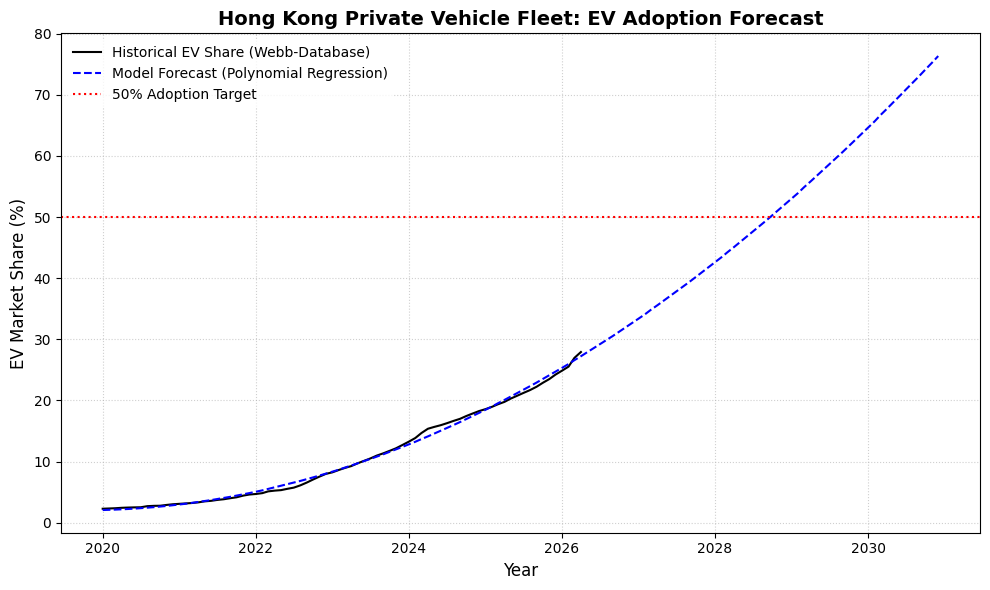

In [28]:
#to find when EV Share crosses 50%
crossing_row = forecast_df[forecast_df['Predicted_EV_Share'] >= 50.0].first_valid_index()
if crossing_row:
    crossing_date = forecast_df.loc[crossing_row, 'Month'].strftime('%B %Y')
    crossing_share = forecast_df.loc[crossing_row, 'Predicted_EV_Share']
    print(f"EV Share is projected to cross 50% in {crossing_date} ({crossing_share:.2f}%)")
else:
    print("EV Share does not cross 50% in this forecast window.")

plt.figure(figsize=(10, 6))
plt.plot(df['Month'], df['Electric share %'], label='Historical EV Share (Webb-Database)', color='black')
plt.plot(forecast_df['Month'], forecast_df['Predicted_EV_Share'], label='Model Forecast (Polynomial Regression)', color='blue', linestyle='--')
plt.axhline(50, color='red', linestyle=':', label='50% Adoption Target')

plt.title('Hong Kong Private Vehicle Fleet: EV Adoption Forecast', fontsize=14, fontweight='bold')
plt.xlabel('Year', fontsize=12)
plt.ylabel('EV Market Share (%)', fontsize=12)
plt.grid(True, linestyle=':', alpha=0.6)
plt.legend(frameon=True, facecolor='white', edgecolor='none')
plt.tight_layout()

plt.show()